In [1]:
import requests
import pandas as pd
import datetime
import time
from typing import List, Dict, Optional, Union
import matplotlib.pyplot as plt

In [2]:
# base_url = "https://fapi.binance.com"
# end_point = "/futures/data/topLongShortPositionRatio"
# url = f"{base_url}{end_point}"

# symbol = "BTCUSDT"
# period = "1h"
# limit = 500
# # str to millisecond
# start_time = int(datetime.datetime.strptime("2025-04-01", "%Y-%m-%d").timestamp() * 1000)
# end_time = None

# params = {"symbol": symbol, "period": period, "limit": limit, "startTime": start_time, "endTime": end_time}

# response = requests.get(url, params=params)
# len(response.json())

In [26]:
class BinanceInvestorAnalyzer:
    """
    Binance API를 활용하여 롱/숏 포지션별 투자자 유형(기관/개인) 비율을 분석하는 클래스
    """

    def __init__(self, api_key: Optional[str] = None, api_secret: Optional[str] = None):
        """
        초기화 메서드

        Args:
            api_key: Binance API 키 (선택적, 퍼블릭 API만 사용할 경우 필요 없음)
            api_secret: Binance API 시크릿 (선택적, 퍼블릭 API만 사용할 경우 필요 없음)
        """
        self.base_url = "https://fapi.binance.com"
        self.api_key = api_key
        self.api_secret = api_secret
        self.headers = {}

        if api_key:
            self.headers["X-MBX-APIKEY"] = api_key

    def get_available_symbols(self) -> List[str]:
        """
        사용 가능한 선물 거래 심볼 목록을 가져옵니다.

        Returns:
            List[str]: 사용 가능한 심볼 목록
        """
        endpoint = "/fapi/v1/exchangeInfo"
        response = requests.get(f"{self.base_url}{endpoint}")
        data = response.json()

        symbols = [
            symbol["symbol"]
            for symbol in data["symbols"]
            if symbol["status"] == "TRADING"
        ]
        return symbols

    def get_position_data(
        self, endpoint_type: str, symbol: str, period: str = "1d", limit: int = 30,
        start_time: Optional[int] = None, end_time: Optional[int] = None
    ) -> pd.DataFrame:
        """
        포지션 데이터를 가져옵니다.

        Args:
            endpoint_type: 엔드포인트 유형 ('top_position')
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)
            start_time: 시작 타임스탬프 (밀리초)
            end_time: 종료 타임스탬프 (밀리초)

        Returns:
            pd.DataFrame: 포지션 데이터
        """
        # 엔드포인트 유형에 따라 적절한 엔드포인트 선택
        endpoints = {
            "top_position": "/futures/data/topLongShortPositionRatio",
        }

        if endpoint_type not in endpoints:
            raise ValueError(
                f"유효하지 않은 엔드포인트 유형입니다. 가능한 값: {', '.join(endpoints.keys())}"
            )

        endpoint = endpoints[endpoint_type]
        params = {"symbol": symbol, "period": period, "limit": limit, "startTime": start_time, "endTime": end_time}

        response = requests.get(f"{self.base_url}{endpoint}", params=params)
        data = response.json()

        if data is None:
            print(f"No data available for {symbol}")
            return pd.DataFrame()

        print(data)
        df = pd.DataFrame(data)
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        df["longPosition"] = df["longAccount"].astype(float)  # 0~1 사이 값 유지
        df["shortPosition"] = df["shortAccount"].astype(float)  # 0~1 사이 값 유지
        df["symbol"] = symbol

        return df

    def get_traders_position(
        self,
        type: str = "top_position",
        symbol: str = "",
        period: str = "1d",
        limit: int = 30,
        startTime: Optional[int] = None,
        endTime: Optional[int] = None
    ) -> pd.DataFrame:
        """
        트레이더 포지션 데이터를 가져옵니다.

        Args:
            type: 데이터 유형 ('top_position': 상위 트레이더 포지션 데이터)
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)
            startTime: 시작 타임스탬프 (밀리초)
            endTime: 종료 타임스탬프 (밀리초)

        Returns:
            pd.DataFrame: 포지션 데이터
        """
        valid_types = ["top_position"]
        if type not in valid_types:
            raise ValueError(
                f"유효하지 않은 데이터 유형입니다. 가능한 값: {', '.join(valid_types)}"
            )

        return self.get_position_data(type, symbol, period, limit, startTime, endTime)

    def calculate_investor_ratio_by_position(
        self, symbol: str, period: str = "1d", limit: int = 30
    ) -> pd.DataFrame:
        """
        롱/숏 포지션별 투자자 유형(기관/개인) 비율을 계산합니다.

        Args:
            symbol: 암호화폐 심볼 (예: 'BTCUSDT', 'ETHUSDT' 등)
            period: 데이터 기간 ('5m', '15m', '30m', '1h', '2h', '4h', '6h', '12h', '1d')
            limit: 반환할 데이터 수 (최대 500)

        Returns:
            pd.DataFrame: 롱/숏 포지션별 투자자 유형 비율 데이터
        """
        # 기관 투자자 데이터 (top trader position ratio)
        institution_data = self.get_traders_position(
            "top_position", symbol, period, limit
        )

        if institution_data.empty:
            return pd.DataFrame()

        # 결과 데이터프레임 생성
        result_df = institution_data.copy()

        # 롱 포지션에서 기관 투자자 비율
        result_df["long_institution_ratio"] = result_df["longPosition"]

        # 롱 포지션에서 개인 투자자 비율 = 1 - 기관 비율
        result_df["long_retail_ratio"] = 1 - result_df["long_institution_ratio"]

        # 숏 포지션에서 기관 투자자 비율
        result_df["short_institution_ratio"] = result_df["shortPosition"]

        # 숏 포지션에서 개인 투자자 비율 = 1 - 기관 비율
        result_df["short_retail_ratio"] = 1 - result_df["short_institution_ratio"]

        # 필요한 열만 선택
        result_df = result_df[
            [
                "timestamp",
                "symbol",
                "long_institution_ratio",
                "long_retail_ratio",
                "short_institution_ratio",
                "short_retail_ratio",
            ]
        ]

        return result_df

    def get_all_investor_ratios(
        self, symbols: List[str], period: str = "1d", limit: int = 30
    ) -> Dict[str, pd.DataFrame]:
        """
        여러 암호화폐에 대한 롱/숏 포지션별 투자자 유형 비율 데이터를 가져옵니다.

        Args:
            symbols: 분석할 암호화폐 심볼 목록
            period: 데이터 기간
            limit: 반환할 데이터 수

        Returns:
            Dict[str, pd.DataFrame]: 각 심볼별 투자자 유형 비율 데이터
        """
        result = {}

        for symbol in symbols:
            print(f"가져오는 중: {symbol}")

            # 롱/숏 포지션별 투자자 유형 비율 계산
            ratio_data = self.calculate_investor_ratio_by_position(
                symbol, period, limit
            )

            if not ratio_data.empty:
                result[symbol] = ratio_data

            # API 호출 제한 방지를 위해 약간의 딜레이
            time.sleep(0.5)

        return result

    def visualize_combined_investor_ratio(self, data: pd.DataFrame, symbol: str):
        """
        롱/숏 포지션에서의 투자자 유형 비율을 하나의 그래프로 시각화

        Args:
            data: 시각화할 데이터
            symbol: 암호화폐 심볼

        Returns:
            matplotlib.figure.Figure: 생성된 그래프
        """
        fig, ax = plt.subplots(figsize=(10, 7))
        font_size = 16

        # 롱 포지션 데이터 (양수 값)
        ax.fill_between(
            data["timestamp"],
            0,
            data["long_institution_ratio"],
            label="Institutional Investors (Long)",
            color="#1f77b4",
            alpha=0.7,
        )
        ax.fill_between(
            data["timestamp"],
            data["long_institution_ratio"],
            1,
            label="Retail Investors (Long)",
            color="#ff7f0e",
            alpha=0.7,
        )

        # 숏 포지션 데이터 (음수 값으로 변환)
        ax.fill_between(
            data["timestamp"],
            0,
            -data["short_institution_ratio"],
            label="Institutional Investors (Short)",
            color="#1f77b4",
            alpha=0.7,
            hatch="/",
        )
        ax.fill_between(
            data["timestamp"],
            -data["short_institution_ratio"],
            -1,
            label="Retail Investors (Short)",
            color="#ff7f0e",
            alpha=0.7,
            hatch="/",
        )

        # 그래프 설정
        ax.set_title(
            f"{symbol} Long/Short Position Investor Type Ratio", fontsize=font_size
        )
        ax.set_xlabel("Date", fontsize=font_size)
        ax.set_ylabel("Ratio (%)", fontsize=font_size)
        ax.set_ylim(-1, 1)
        ax.grid(True, alpha=0.3)

        # 0선 강조
        ax.axhline(y=0, color="black", linestyle="-", linewidth=1)

        # y축 레이블 조정
        ax.set_yticks([-1, -0.75, -0.50, -0.25, 0, 0.25, 0.5, 0.75, 1])
        ax.set_yticklabels(
            ["1", "0.75", "0.50", "0.25", "0", ".0.25", "0.50", "0.75", "1"],
            fontsize=font_size - 2,
        )

        # 범례 추가
        ax.legend(loc="lower right", fontsize=font_size - 2)
        ax.tick_params(axis="x", rotation=45, labelsize=font_size - 2)

        # 설명 텍스트 추가
        ax.text(
            0.02, 0.95, "Long Position", transform=ax.transAxes, fontsize=font_size - 4
        )
        ax.text(
            0.02, 0.05, "Short Position", transform=ax.transAxes, fontsize=font_size - 4
        )

        plt.tight_layout()

        return plt


    def get_data_with_pagination(
        self,
        symbol: str,
        data_type: str = "top_position",
        period: str = "1d",
        start_time: Optional[int] = None,
        end_time: Optional[int] = None,
        max_iterations: int = 10,
        limit: int = 500,
    ) -> pd.DataFrame:
        """
        페이지네이션을 이용하여 더 많은 데이터를 가져오는 메서드
        
        Args:
            symbol (str): 암호화폐 심볼 (예: 'BTCUSDT')
            data_type (str): 데이터 타입 ("top_position")
            period (str): 데이터 기간 ('1d', '4h' 등)
            start_time (int, optional): 시작 타임스탬프 (밀리초)
            end_time (int, optional): 종료 타임스탬프 (밀리초, 기본값: 현재 시간)
            max_iterations (int): 최대 API 요청 횟수
            limit (int): 각 요청당 최대 데이터 개수
            
        Returns:
            pd.DataFrame: 페이지네이션으로 수집된 전체 데이터
        """
        if end_time is None:
            end_time = int(time.time() * 1000)  # 현재 시간을 밀리초로
            
        all_data = None
        current_end_time = end_time
            
        for iteration in range(max_iterations):
            
            print(iteration)
            
            # 데이터 타입에 따른 API 호출 함수 선택
            if data_type == "top_position":
                data = self.get_traders_position(
                    type=data_type,
                    symbol=symbol,
                    period=period,
                    limit=limit,
                    endTime=current_end_time,
                    startTime=start_time
                )
            else:
                raise ValueError(f"지원되지 않는 데이터 타입: {data_type}")

            if data is None or len(data) == 0:
                print(f"더 이상 데이터가 없습니다. (반복 {iteration+1}/{max_iterations})")
                break
            
            print(data)
            data.loc[:, "timestamp"] = pd.to_datetime(data.loc[:, "timestamp"], unit="ms")
            data = data.sort_values("timestamp")
            
            if all_data is None:
                all_data = data
            else:
                all_data = pd.concat([all_data, data])
            print(
                f"반복 {iteration+1}/{max_iterations}: {len(data)}개 데이터 수집 (총: {len(all_data)}개)"
            )
            
            # 다음 요청의 종료 시간을 현재 배치의 가장 첫번째 timestamp보다 1ms 이전으로 설정
            # timestamp 객체를 정수형 타임스탬프로 변환 후 연산
            current_end_time = int(data.loc[0, "timestamp"].timestamp() * 1000) - 1
            
            if current_end_time < start_time:
                print(f"{current_end_time} < {start_time}")
                break

            # API 호출 제한 방지를 위해 약간의 딜레이
            time.sleep(1)

        # 모든 데이터를 DataFrame으로 변환
        if not all_data.empty:
            return all_data.sort_values("timestamp")
        else:
            return pd.DataFrame()

In [40]:
analyzer = BinanceInvestorAnalyzer()

# 30일 전부터 현재까지
end_time = int(time.time() * 1000)  # 현재 시간 (밀리초)
start_time = int(datetime.datetime.strptime("2025-03-05", "%Y-%m-%d").timestamp() * 1000)

eth_data = analyzer.get_data_with_pagination(
    symbol='BTCUSDT',
    data_type='top_position',
    period='1h',
    start_time=start_time,
    end_time=end_time,
    max_iterations=3,
    limit=500
)

0
[{'symbol': 'BTCUSDT', 'longAccount': '0.6621', 'longShortRatio': '1.9593', 'shortAccount': '0.3379', 'timestamp': 1741950000000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6598', 'longShortRatio': '1.9391', 'shortAccount': '0.3402', 'timestamp': 1741953600000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6529', 'longShortRatio': '1.8807', 'shortAccount': '0.3471', 'timestamp': 1741957200000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6452', 'longShortRatio': '1.8187', 'shortAccount': '0.3548', 'timestamp': 1741960800000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6499', 'longShortRatio': '1.8564', 'shortAccount': '0.3501', 'timestamp': 1741964400000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6439', 'longShortRatio': '1.8084', 'shortAccount': '0.3561', 'timestamp': 1741968000000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6441', 'longShortRatio': '1.8101', 'shortAccount': '0.3559', 'timestamp': 1741971600000}, {'symbol': 'BTCUSDT', 'longAccount': '0.6455', 'longShortRatio': '1.8211', 'shortAccoun

In [41]:
eth_data

,symbol,longAccount,longShortRatio,shortAccount,timestamp,longPosition,shortPosition
0,BTCUSDT,0.6537,1.8878,0.3463,2025-03-04 15:00:00,0.6537,0.3463
1,BTCUSDT,0.6520,1.8733,0.3480,2025-03-04 16:00:00,0.6520,0.3480
2,BTCUSDT,0.6504,1.8601,0.3496,2025-03-04 17:00:00,0.6504,0.3496
3,BTCUSDT,0.6405,1.7816,0.3595,2025-03-04 18:00:00,0.6405,0.3595
4,BTCUSDT,0.6321,1.7185,0.3679,2025-03-04 19:00:00,0.6321,0.3679
...,...,...,...,...,...,...,...
495,BTCUSDT,0.6373,1.7571,0.3627,2025-04-04 02:00:00,0.6373,0.3627
496,BTCUSDT,0.6386,1.7667,0.3614,2025-04-04 03:00:00,0.6386,0.3614
497,BTCUSDT,0.6430,1.8010,0.3570,2025-04-04 04:00:00,0.6430,0.3570
498,BTCUSDT,0.6435,1.8052,0.3565,2025-04-04 05:00:00,0.6435,0.3565


가져오는 중: BTCUSDT
              timestamp   symbol  long_institution_ratio  long_retail_ratio  \
0   2025-03-14 10:00:00  BTCUSDT                  0.6605             0.3395   
1   2025-03-14 11:00:00  BTCUSDT                  0.6621             0.3379   
2   2025-03-14 12:00:00  BTCUSDT                  0.6598             0.3402   
3   2025-03-14 13:00:00  BTCUSDT                  0.6529             0.3471   
4   2025-03-14 14:00:00  BTCUSDT                  0.6452             0.3548   
..                  ...      ...                     ...                ...   
495 2025-04-04 01:00:00  BTCUSDT                  0.6386             0.3614   
496 2025-04-04 02:00:00  BTCUSDT                  0.6373             0.3627   
497 2025-04-04 03:00:00  BTCUSDT                  0.6386             0.3614   
498 2025-04-04 04:00:00  BTCUSDT                  0.6430             0.3570   
499 2025-04-04 05:00:00  BTCUSDT                  0.6435             0.3565   

     short_institution_ratio  short

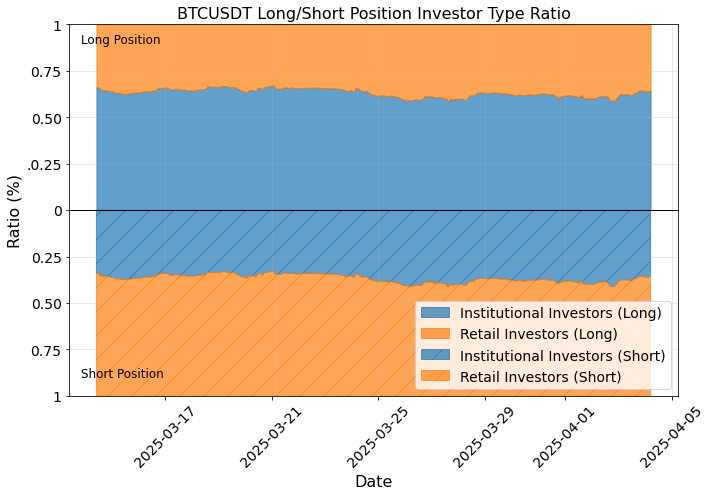

BTCUSDT visualization completed

===== ETHUSDT Investor Type Analysis =====
Long Position: Institutional 0.72%, Retail 0.28%
Short Position: Institutional 0.28%, Retail 0.72%


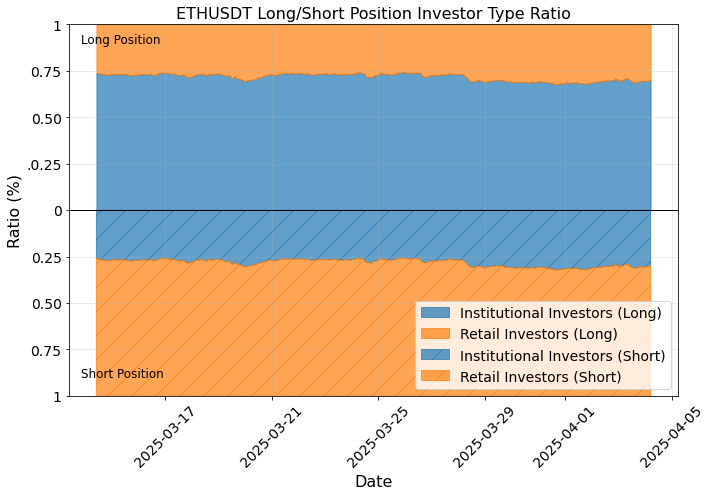

ETHUSDT visualization completed

===== SOLUSDT Investor Type Analysis =====
Long Position: Institutional 0.68%, Retail 0.32%
Short Position: Institutional 0.32%, Retail 0.68%


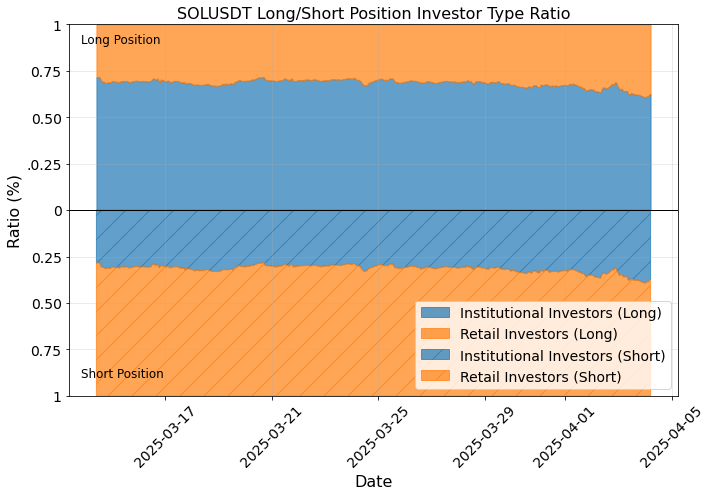

SOLUSDT visualization completed

===== BNBUSDT Investor Type Analysis =====
Long Position: Institutional 0.52%, Retail 0.48%
Short Position: Institutional 0.48%, Retail 0.52%


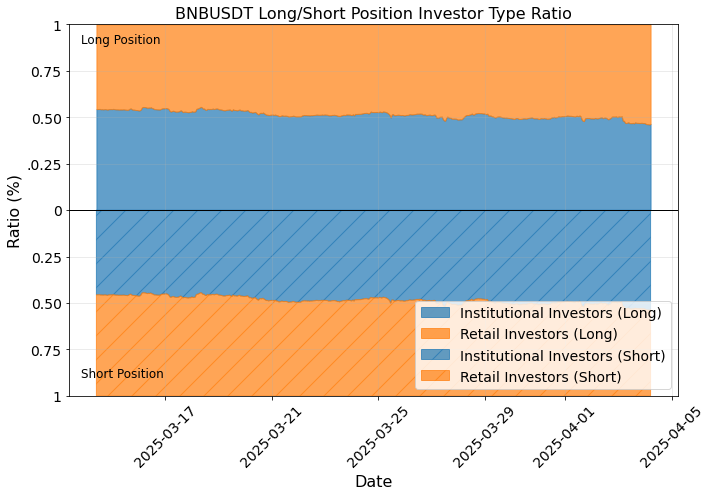

BNBUSDT visualization completed


In [3]:
analyzer = BinanceInvestorAnalyzer()

# 분석할 암호화폐 목록
crypto_symbols = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "BNBUSDT"]
limit = 500

# 데이터 가져오기
investor_ratios = analyzer.get_all_investor_ratios(
    crypto_symbols, period="1h", limit=limit
)

# 결과 출력 및 시각화
for symbol, data in investor_ratios.items():
    print(f"\n===== {symbol} Investor Type Analysis =====")

    # 최신 데이터 출력
    mean = data.loc[
        :,
        [
            "long_institution_ratio",
            "long_retail_ratio",
            "short_institution_ratio",
            "short_retail_ratio",
        ],
    ].mean()
    print(
        f"Long Position: Institutional {mean['long_institution_ratio']:.2f}%, Retail {mean['long_retail_ratio']:.2f}%"
    )
    print(
        f"Short Position: Institutional {mean['short_institution_ratio']:.2f}%, Retail {mean['short_retail_ratio']:.2f}%"
    )

    # 시각화
    # 3. 롱/숏 투자자 유형 비율 통합 그래프
    combined_plt = analyzer.visualize_combined_investor_ratio(data, symbol)
    combined_plt.show()

    plt.close("all")
    print(f"{symbol} visualization completed")